# Example use-case for training and evaluating a TinyConv model on the MNIST dataset.

In [1]:
import torch
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, ToTensor

from eigen.data import load_dataset
from eigen.metrics import accuracy
from eigen.plotting import plot_image_grid
from eigen.trainer import Trainer
from models.tiny_conv import TinyConv

In [2]:
torch.manual_seed(0)
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [3]:
print("Loading data...")
train_data = MNIST(
    root="data", train=True, download=True, transform=Compose([ToTensor()])
)
test_data = MNIST(
    root="data", train=False, download=True, transform=Compose([ToTensor()])
)
train_loader, test_loader, val_loader = load_dataset(
    train_data, test_data, val_split=0.1
)
print("Data loaded successfully!")

Loading data...
Data loaded successfully!


Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


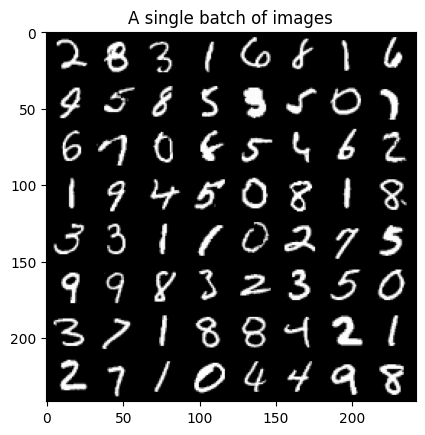

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'A single batch of images'}>)

In [4]:
# display image and label.
images, labels = next(iter(train_loader))
print(
    f"Feature batch shape: {images.size()}",
    f"Labels batch shape: {labels.size()}",
    sep="\n",
)
plot_image_grid(images, ax_kws=dict(title="A single batch of images"))

In [5]:
# model initialization
model = TinyConv()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

trainer = Trainer(
    model,
    optimizer,
    criterion,
    metrics={"accuracy": accuracy},
    n_epochs=10,
    device=device,
)

In [6]:
%%capture
# training
trainer.fit(train_loader, val_loader)

In [7]:
# inference
test_accuracy = trainer.eval(test_loader)
print(f"Test accuracy: {test_accuracy['accuracy']}%")

Test accuracy: 98.46%


In [8]:
# serialize model to onnx
torch.onnx.export(
    model,
    images.to(device),
    "../checkpoints/TinyConv/tinyconv.onnx",
    input_names=["input"],
    output_names=["output"],
);

[torch.onnx] Obtain model graph for `TinyConv([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TinyConv([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
